In [2]:
"""
Mutual Fund Analytics Capstone Project

Notebook: 04_performance_analytics.ipynb

Purpose:
Analyzes mutual fund performance using return-based and risk-adjusted metrics
including CAGR, Alpha, Beta, Sharpe Ratio, and Sortino Ratio.

Author: Yash Ridla
Date: June 2026
"""

'\nMutual Fund Analytics Capstone Project\n\nNotebook: 04_performance_analytics.ipynb\n\nPurpose:\nAnalyzes mutual fund performance using return-based and risk-adjusted metrics\nincluding CAGR, Alpha, Beta, Sharpe Ratio, and Sortino Ratio.\n\nAuthor: Yash Ridla\nDate: June 2026\n'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

performance = pd.read_csv('../Data/Raw/07_scheme_performance.csv')
benchmark = pd.read_csv('../Data/Raw/10_benchmark_indices.csv')
nav = pd.read_csv('../Data/Raw/02_nav_history.csv')
fund_master = pd.read_csv('../Data/Raw/01_fund_master.csv')


# Task 1

In [34]:
# Daily Return Calculation
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [9]:
# Annualised Return
annual_returns = nav.groupby('amfi_code').apply(
    lambda x: pd.Series({
        'annualised_return':
        ((1 + x['daily_return'].dropna()).prod()) **
        (252 / len(x['daily_return'].dropna())) - 1
    })
).reset_index()

annual_returns.head()

C:\Users\user\AppData\Local\Temp\ipykernel_2364\2550713891.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  annual_returns = nav.groupby('amfi_code').apply(


,amfi_code,annualised_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [10]:
annual_returns.to_csv(
    '../Data/Processed/returns_computed.csv',
    index=False
)

print("returns_computed.csv saved successfully")

returns_computed.csv saved successfully


## Task 1: Daily & Annualised Return Calculation

- Calculated daily returns using NAV history.
- Computed annualised returns using trading-day adjustment (252 days).
- Exported results to returns_computed.csv.

# TASK 2

In [18]:
cagr_nav = pd.merge(
    nav,
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

cagr_nav.head()

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


In [13]:
selected_funds = [
    'SBI Bluechip Fund - Regular Plan - Growth',
    'HDFC Top 100 Fund - Regular Plan - Growth'
]

fund_data = cagr_nav[
    cagr_nav['scheme_name'].isin(selected_funds)
]

In [19]:
def calculate_cagr(df, years):

    end_date = df['date'].max()
    start_date = end_date - pd.DateOffset(years=years)

    period_df = df[df['date'] >= start_date]

    if len(period_df) < 2:
        return np.nan

    nav_start = period_df.iloc[0]['nav']
    nav_end = period_df.iloc[-1]['nav']

    return (nav_end / nav_start) ** (1/years) - 1

In [22]:
cagr_report = []

for fund in cagr_nav['scheme_name'].dropna().unique():

    temp = cagr_nav[
        cagr_nav['scheme_name'] == fund
    ].sort_values('date')

    cagr_report.append({
        'scheme_name': fund,
        'cagr_1yr': calculate_cagr(temp,1),
        'cagr_3yr': calculate_cagr(temp,3),
        'cagr_5yr': calculate_cagr(temp,5)
    })

cagr_report = pd.DataFrame(cagr_report)

cagr_report.head()

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,SBI Bluechip Fund - Regular Plan - Growth,0.604373,0.304565,0.223849
1,SBI Bluechip Fund - Direct Plan - Growth,0.057061,0.162674,0.187131
2,SBI Small Cap Fund - Regular Plan - Growth,0.827761,0.266699,0.280332
3,SBI Small Cap Fund - Direct Plan - Growth,0.139478,-0.013374,0.018056
4,SBI Magnum Gilt Fund - Regular Plan - Growth,0.055220,0.058404,0.051644


In [24]:
cagr_report.to_csv(
    '../Data/Processed/cagr_report.csv',
    index=False
)

print("CAGR Report Saved")

CAGR Report Saved


## Task 2: CAGR Calculation

- Calculated 1-Year, 3-Year and 5-Year CAGR for all mutual funds.
- Used NAV history and CAGR formula:
  CAGR = (NAV_end / NAV_start)^(1/n) - 1
- Verified results for SBI Bluechip and HDFC Top 100 funds.
- Exported output to cagr_report.csv.

# TASK 3

In [25]:
sharpe_nav = nav.copy()

sharpe_nav['daily_return'] = (
    sharpe_nav
    .groupby('amfi_code')['nav']
    .pct_change()
)

sharpe_nav.head()

,amfi_code,date,nav,daily_return
0,119551,2022-01-03,54.3856,NaN
1,119551,2022-01-04,54.3474,-0.000702
2,119551,2022-01-05,54.6869,0.006247
3,119551,2022-01-06,55.4550,0.014045
4,119551,2022-01-07,55.3692,-0.001547


In [26]:
rf = 0.065

sharpe_values = sharpe_nav.groupby('amfi_code').agg({
    'daily_return':['mean','std']
})

sharpe_values.columns = ['avg_return','std_return']

sharpe_values = sharpe_values.reset_index()

sharpe_values['sharpe_ratio'] = (
    ((sharpe_values['avg_return'] * 252) - rf)
    /
    (sharpe_values['std_return'] * np.sqrt(252))
)

sharpe_values.head()

,amfi_code,avg_return,std_return,sharpe_ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [27]:
sharpe_values = pd.merge(
    sharpe_values,
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

sharpe_values.head()

,amfi_code,avg_return,std_return,sharpe_ratio,scheme_name
0,100016,0.000142,0.009164,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.000170,0.002460,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.000424,0.016251,0.162661,ABSL Small Cap Fund - Regular - Growth


In [28]:
sharpe_values['sharpe_ratio'].describe()

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: sharpe_ratio, dtype: float64

In [29]:
sharpe_values.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

,amfi_code,avg_return,std_return,sharpe_ratio,scheme_name
34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,0.000843,0.009048,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [30]:
sharpe_values.to_csv(
    '../Data/Processed/sharpe_values.csv',
    index=False
)

## Task 3: Sharpe Ratio

- Calculated Sharpe Ratio using:
  Sharpe = (Rp - Rf) / Std(Rp)
- Assumed Risk Free Rate = 6.5%
- Annualised using √252.
- Exported results to sharpe_values.csv.

# TASK 4

In [31]:
rf = 0.065
daily_rf = rf / 252

In [36]:
sortino_values = nav.groupby('amfi_code').apply(
    lambda x: pd.Series({
        'avg_return': x['daily_return'].mean(),

        'downside_std':
        x.loc[x['daily_return'] < 0, 'daily_return'].std(),

        'sortino_ratio':
        ((x['daily_return'].mean() - daily_rf) /
         x.loc[x['daily_return'] < 0, 'daily_return'].std())
         * (252 ** 0.5)
    })
).reset_index()

C:\Users\user\AppData\Local\Temp\ipykernel_2364\3999937113.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sortino_values = nav.groupby('amfi_code').apply(


In [37]:
sortino_values = pd.merge(
    sortino_values,
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

sortino_values.head()

,amfi_code,avg_return,downside_std,sortino_ratio,scheme_name
0,100016,0.000142,0.005261,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.000170,0.001481,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.001080,0.007133,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.000852,0.005238,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.000424,0.009555,0.276644,ABSL Small Cap Fund - Regular - Growth


In [38]:
sortino_values['sortino_ratio'].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: sortino_ratio, dtype: float64

In [39]:
sortino_values.sort_values(
    'sortino_ratio',
    ascending=False
).head(10)

,amfi_code,avg_return,downside_std,sortino_ratio,scheme_name
34,148567,0.001074,0.005428,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.001082,0.005531,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,0.001124,0.006404,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.000917,0.004887,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.001161,0.007067,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.001055,0.006750,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,0.000865,0.005211,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,0.001080,0.007133,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,0.000843,0.005145,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,0.000852,0.005238,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [40]:
sortino_values.to_csv(
    '../Data/Processed/sortino_values.csv',
    index=False
)

## Task 4: Sortino Ratio Analysis

### Objective
Calculate the Sortino Ratio for each mutual fund using downside risk instead of total volatility.

### Methodology
- Risk-Free Rate (Rf) assumed as **6.5%** (RBI repo rate proxy).
- Daily Risk-Free Rate = Rf / 252.
- Downside Standard Deviation calculated using only negative return days.
- Sortino Ratio computed as:

Sortino Ratio = (Rp - Rf) / Downside Std

- Annualised using √252.

### Output
- Calculated downside risk for all funds.
- Computed annualised Sortino Ratios.
- Identified top-performing funds based on risk-adjusted returns.
- Exported results to **sortino_values.csv**.

# TASK 5 

In [42]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100['date'] = pd.to_datetime(nifty100['date'])

nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value'].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [43]:
alpha_beta_df = pd.merge(
    nav,
    nifty100[['date', 'benchmark_return']],
    on='date',
    how='inner'
)

alpha_beta_df.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [44]:
from scipy.stats import linregress

results = []

for fund in alpha_beta_df['amfi_code'].unique():

    temp = alpha_beta_df[
        alpha_beta_df['amfi_code'] == fund
    ].dropna()

    if len(temp) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            temp['benchmark_return'],
            temp['daily_return']
        )

        results.append({
            'amfi_code': fund,
            'alpha': intercept * 252,
            'beta': slope
        })

alpha_beta = pd.DataFrame(results)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [45]:
alpha_beta = pd.merge(
    alpha_beta,
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

alpha_beta.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [46]:
alpha_beta.describe()

,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958
std,14534.998667,0.087528,0.035194
min,100016.000000,0.028969,-0.066951
25%,118632.750000,0.068612,-0.023937
50%,119551.500000,0.162326,-0.000067
75%,120842.250000,0.221723,0.017026
max,149324.000000,0.303370,0.103497


In [47]:
alpha_beta.sort_values(
    'alpha',
    ascending=False
).head(10)

,amfi_code,alpha,beta,scheme_name
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth


In [48]:
alpha_beta.to_csv(
    '../Data/Processed/alpha_beta.csv',
    index=False
)

## Task 5: Alpha & Beta Analysis vs Benchmark

### Objective
Evaluate mutual fund performance relative to the benchmark by calculating Alpha and Beta using regression analysis.

### Methodology
- Selected **NIFTY100** as the benchmark index.
- Calculated daily returns for mutual funds and benchmark index.
- Merged fund returns with benchmark returns using common dates.
- Applied Ordinary Least Squares (OLS) regression using `scipy.stats.linregress`.
- Calculated:
  - **Beta** = Regression slope
  - **Alpha** = Regression intercept × 252 (annualised)

### Formula
Beta = Slope of Regression Line

Alpha = Intercept × 252

### Output
- Computed Alpha and Beta values for all mutual funds.
- Identified funds generating excess returns relative to benchmark performance.
- Ranked funds based on Alpha values.
- Exported results to **alpha_beta.csv**.

# TASK 6

In [49]:
def calculate_max_drawdown(df):

    df = df.sort_values('date').copy()

    df['running_max'] = df['nav'].cummax()

    df['drawdown'] = (
        df['nav'] / df['running_max']
    ) - 1

    max_dd = df['drawdown'].min()

    worst_row = df.loc[
        df['drawdown'].idxmin()
    ]

    return pd.Series({
        'max_drawdown': max_dd,
        'worst_date': worst_row['date']
    })

In [51]:
max_drawdown = (
    cagr_nav.groupby('amfi_code')
    .apply(calculate_max_drawdown)
    .reset_index()
)

max_drawdown.head()

C:\Users\user\AppData\Local\Temp\ipykernel_2364\556850266.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_max_drawdown)


,amfi_code,max_drawdown,worst_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [52]:
max_drawdown = pd.merge(
    max_drawdown,
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

max_drawdown.head()

,amfi_code,max_drawdown,worst_date,scheme_name
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,2023-07-28,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,2022-05-12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,2023-07-05,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth


In [53]:
max_drawdown.sort_values(
    'max_drawdown'
).head(10)

,amfi_code,max_drawdown,worst_date,scheme_name
22,119599,-0.525742,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,2023-05-22,Axis Bluechip Fund - Direct - Growth


In [55]:
max_drawdown.to_csv(
    '../Data/Processed/max_drawdown.csv',
    index=False
)

In [ ]:
max_drawdown.head()

## Task 6: Maximum Drawdown Analysis

### Objective
Measure the maximum decline in fund NAV from its historical peak and identify the worst drawdown period for each mutual fund.

### Methodology
- Sorted NAV history by date for each fund.
- Calculated the running maximum NAV using cumulative maximum.
- Computed drawdown for each observation as:

  Drawdown = (NAV / Running Max) - 1

- Identified the minimum drawdown value as the Maximum Drawdown.
- Recorded the corresponding date of the worst drawdown.

### Formula

Max Drawdown = min((NAV / Running Max) - 1)

### Output
- Calculated Maximum Drawdown for all mutual funds.
- Identified the worst drawdown period for each fund.
- Compared downside risk across funds.
- Ranked funds based on drawdown severity.
- Exported results to **max_drawdown.csv**.

# TASK 7

In [62]:
scorecard = performance[
    ['amfi_code',
     'scheme_name',
     'return_3yr_pct',
     'expense_ratio_pct']
].copy()

scorecard = pd.merge(
    scorecard,
    sharpe_values[['amfi_code','sharpe_ratio']],
    on='amfi_code'
)

scorecard = pd.merge(
    scorecard,
    alpha_beta[['amfi_code','alpha']],
    on='amfi_code'
)

scorecard = pd.merge(
    scorecard,
    max_drawdown[['amfi_code','max_drawdown']],
    on='amfi_code'
)

In [63]:
scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287


In [64]:
scorecard['return_rank'] = scorecard['return_3yr_pct'].rank(ascending=False)

scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=False)

scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=False)

scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)

scorecard['drawdown_rank'] = scorecard['max_drawdown'].rank(ascending=False)

In [65]:
scorecard['score'] = (
    scorecard['return_rank'] * 0.30 +
    scorecard['sharpe_rank'] * 0.25 +
    scorecard['alpha_rank'] * 0.20 +
    scorecard['expense_rank'] * 0.15 +
    scorecard['drawdown_rank'] * 0.10
)

In [66]:
scorecard = scorecard.sort_values('score')

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-0.181885,8.0,5.0,3.0,15.0,25.0,9.000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.129740,11.0,2.0,5.0,22.0,13.0,9.400
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,17.0,20.0,10.500
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,10.750
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-0.112657,17.0,1.0,7.0,23.0,8.0,11.000
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-0.311719,6.0,13.0,2.0,26.5,37.0,13.125
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-0.172481,9.0,6.0,8.0,38.0,22.0,13.700
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,-0.125883,20.0,10.0,13.0,12.0,12.0,14.100
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-0.209609,15.0,11.0,9.0,17.0,28.0,14.400
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,-0.163967,23.0,3.0,4.0,36.5,21.0,16.025


In [67]:
scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(
    ascending=True
)

In [68]:
scorecard['drawdown_rank'] = scorecard['max_drawdown'].rank(
    ascending=False
)

In [70]:
scorecard.to_csv(
    '../Data/Processed/fund_scorecard.csv',
    index=False
)

### Objective
Build a composite Fund Scorecard (0–100) by combining multiple performance and risk metrics to rank mutual funds on a risk-adjusted basis.

### Methodology

The scorecard was constructed using the following weighted ranking framework:

- 30% × 3-Year Return Rank
- 25% × Sharpe Ratio Rank
- 20% × Alpha Rank
- 15% × Expense Ratio Rank (Inverse)
- 10% × Maximum Drawdown Rank (Inverse)

#### Ranking Logic

- Higher 3-Year Returns → Better Rank
- Higher Sharpe Ratio → Better Rank
- Higher Alpha → Better Rank
- Lower Expense Ratio → Better Rank
- Lower Maximum Drawdown → Better Rank

#### Composite Score Formula

Score =
(0.30 × Return Rank)
+ (0.25 × Sharpe Rank)
+ (0.20 × Alpha Rank)
+ (0.15 × Expense Rank)
+ (0.10 × Drawdown Rank)

Funds were then sorted based on the final composite score.

### Output

- Merged return, risk, and cost metrics into a single scorecard.
- Generated weighted rankings across all funds.
- Calculated composite fund scores.
- Identified top-performing funds using a risk-adjusted framework.
- Exported results to **fund_scorecard.csv**.

# TASK 8

In [73]:
top5_funds = scorecard.head(5)['amfi_code'].tolist()

top5_funds

[120505, 120843, 100033, 119598, 148567]

In [74]:
end_date = nav['date'].max()

start_date = end_date - pd.DateOffset(years=3)

nav_3yr = nav[
    (nav['date'] >= start_date) &
    (nav['date'] <= end_date)
].copy()

nav_3yr.head()

,amfi_code,date,nav,daily_return
6115,100016,2023-05-29,561.5519,-0.008540
6116,100016,2023-05-30,565.9312,0.007799
6117,100016,2023-05-31,562.0590,-0.006842
6118,100016,2023-06-01,565.0931,0.005398
6119,100016,2023-06-02,563.6716,-0.002516


In [76]:
top5_nav = nav_3yr[
    nav_3yr['amfi_code'].isin(top5_funds)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
8415,100033,2023-05-29,147.2155,0.004216
8416,100033,2023-05-30,147.2007,-0.000101
8417,100033,2023-05-31,147.4640,0.001789
8418,100033,2023-06-01,146.5954,-0.005890
8419,100033,2023-06-02,145.8015,-0.005416


In [78]:
top5_nav['normalized_nav'] = (
    top5_nav.groupby('amfi_code')['nav']
    .transform(lambda x: x / x.iloc[0] * 100)
)

top5_nav.head()

,amfi_code,date,nav,daily_return,normalized_nav
8415,100033,2023-05-29,147.2155,0.004216,100.000000
8416,100033,2023-05-30,147.2007,-0.000101,99.989947
8417,100033,2023-05-31,147.4640,0.001789,100.168800
8418,100033,2023-06-01,146.5954,-0.005890,99.578781
8419,100033,2023-06-02,145.8015,-0.005416,99.039503


In [79]:
top5_nav[['amfi_code','date','nav','normalized_nav']].head(10)

,amfi_code,date,nav,normalized_nav
8415,100033,2023-05-29,147.2155,100.000000
8416,100033,2023-05-30,147.2007,99.989947
8417,100033,2023-05-31,147.4640,100.168800
8418,100033,2023-06-01,146.5954,99.578781
8419,100033,2023-06-02,145.8015,99.039503
8420,100033,2023-06-05,146.4025,99.447748
8421,100033,2023-06-06,148.1654,100.645245
8422,100033,2023-06-07,147.2075,99.994566
8423,100033,2023-06-08,145.7830,99.026937
8424,100033,2023-06-09,146.9565,99.824067


In [82]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

benchmark['date'].head()

0   2022-01-03
1   2022-01-04
2   2022-01-05
3   2022-01-06
4   2022-01-07
Name: date, dtype: datetime64[ns]

In [83]:
end_date = benchmark['date'].max()

start_date = end_date - pd.DateOffset(years=3)

benchmark_3yr = benchmark[
    (benchmark['date'] >= start_date) &
    (benchmark['date'] <= end_date)
].copy()

benchmark_3yr.head()

,date,index_name,close_value
365,2023-05-29,NIFTY50,24688.69
366,2023-05-30,NIFTY50,24558.17
367,2023-05-31,NIFTY50,24476.07
368,2023-06-01,NIFTY50,24375.89
369,2023-06-02,NIFTY50,24398.93


In [86]:
nifty50 = benchmark_3yr[
    benchmark_3yr['index_name'] == 'NIFTY50'
].copy()

nifty50['normalized_index'] = (
    nifty50['close_value']
    / nifty50['close_value'].iloc[0]
    * 100
)

nifty50.head()

,date,index_name,close_value,normalized_index
365,2023-05-29,NIFTY50,24688.69,100.000000
366,2023-05-30,NIFTY50,24558.17,99.471337
367,2023-05-31,NIFTY50,24476.07,99.138796
368,2023-06-01,NIFTY50,24375.89,98.733023
369,2023-06-02,NIFTY50,24398.93,98.826345


In [87]:
nifty100 = benchmark_3yr[
    benchmark_3yr['index_name'] == 'NIFTY100'
].copy()

nifty100['normalized_index'] = (
    nifty100['close_value']
    / nifty100['close_value'].iloc[0]
    * 100
)

nifty100.head()

,date,index_name,close_value,normalized_index
1515,2023-05-29,NIFTY100,15324.41,100.000000
1516,2023-05-30,NIFTY100,15299.69,99.838689
1517,2023-05-31,NIFTY100,15248.41,99.504059
1518,2023-06-01,NIFTY100,15139.50,98.793363
1519,2023-06-02,NIFTY100,15194.66,99.153312


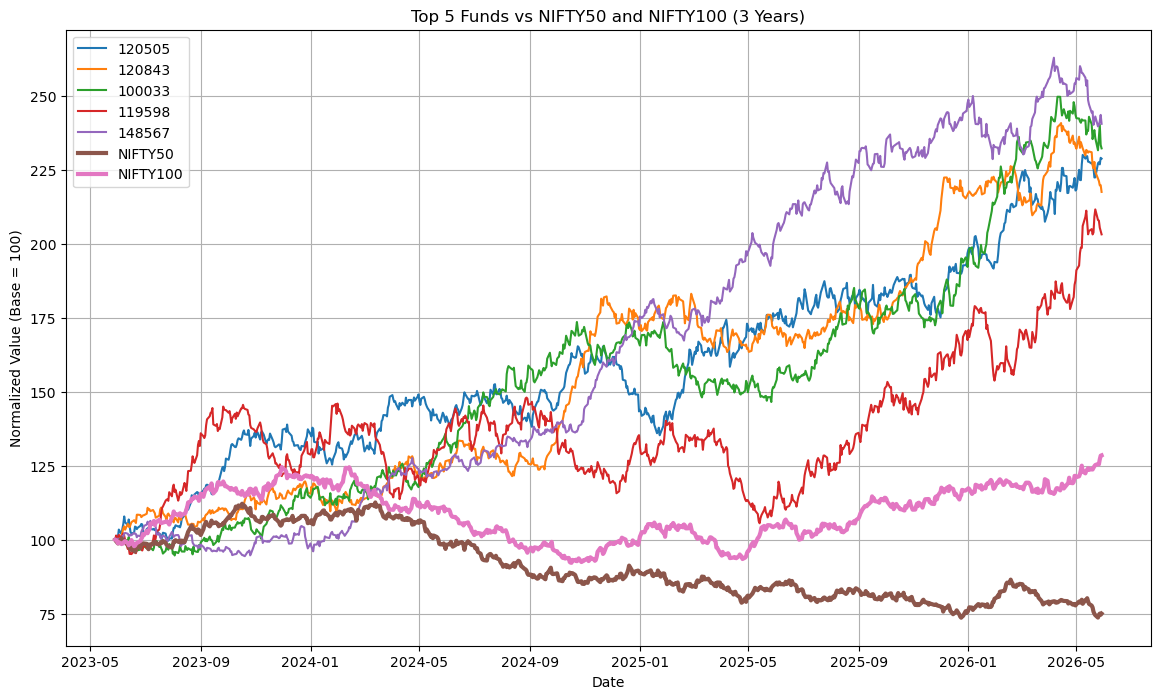

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for fund in top5_funds:

    fund_data = top5_nav[
        top5_nav['amfi_code'] == fund
    ]

    plt.plot(
        fund_data['date'],
        fund_data['normalized_nav'],
        label=str(fund)
    )

plt.plot(
    nifty50['date'],
    nifty50['normalized_index'],
    linewidth=3,
    label='NIFTY50'
)

plt.plot(
    nifty100['date'],
    nifty100['normalized_index'],
    linewidth=3,
    label='NIFTY100'
)

plt.title('Top 5 Funds vs NIFTY50 and NIFTY100 (3 Years)')
plt.xlabel('Date')
plt.ylabel('Normalized Value (Base = 100)')
plt.legend()
plt.grid(True)

plt.savefig(
    "../Reports/benchmark_chart.png",
    bbox_inches="tight"
)

plt.show()

In [91]:
top5_nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return', 'normalized_nav'], dtype='object')

In [92]:
#Tracking Error
import numpy as np

tracking_errors = []

for fund in top5_funds:

    fund_data = top5_nav[
        top5_nav['amfi_code'] == fund
    ][['date','daily_return']]

    benchmark_returns = nifty50[['date']].copy()

    benchmark_returns['benchmark_return'] = (
        nifty50['close_value'].pct_change()
    )

    merged = pd.merge(
        fund_data,
        benchmark_returns,
        on='date',
        how='inner'
    )

    tracking_error = np.std(
        merged['daily_return'] -
        merged['benchmark_return']
    )

    tracking_errors.append(
        [fund, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=['amfi_code','tracking_error']
)

tracking_error_df

,amfi_code,tracking_error
0,120505,0.014382
1,120843,0.012910
2,100033,0.014367
3,119598,0.017725
4,148567,0.012079


In [93]:
tracking_error_df.to_csv(
    '../Data/Processed/tracking_error.csv',
    index=False
)

## TASK 8 : Benchmark Comparison & Tracking Error Analysis

### Objective
Compare the performance of the top 5 ranked mutual funds against NIFTY50 and NIFTY100 benchmarks over the last 3 years and compute tracking error.

### Steps Performed
- Selected the top 5 funds based on the fund scorecard.
- Filtered NAV history for the latest 3-year period.
- Normalized NAV values using a base value of 100.
- Filtered benchmark data for NIFTY50 and NIFTY100.
- Normalized benchmark index values for comparison.
- Plotted fund and benchmark performance on a single chart.
- Computed tracking error using the standard deviation of active returns.
- Saved chart and tracking error results.

### Formula

Normalized Value = (Current Value / Initial Value) × 100

Tracking Error = Std(Fund Return − Benchmark Return)

### Libraries Used
- Pandas
- NumPy
- Matplotlib

### Output
- Compared Top 5 Funds with NIFTY50 and NIFTY100 over 3 years.
- Generated benchmark comparison chart.
- Calculated tracking error for each top-performing fund.
- Exported chart as **benchmark_chart.png**.
- Exported results as **tracking_error.csv**.